# Theoretical RegSeq


In [29]:
import os
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import equinox as eqx

from promdis.processing import get_sequence_arrays_and_counts, gene_seq_to_array
from promdis.jax.core import compute_mean_expression_shift
from promdis.jax.core import compute_expression_shift_by_mutation
from promdis.jax.core import compute_expression_shift_by_pairwise_mutation
from promdis.jax.core import compare_sequences
from promdis.pl import plot_data_2d

In [30]:
#DATDIR = "../data/treg/TFF"
#FNAME = 'TFF20k.csv'

#GENE = 'tff-rpsB-tsf'
#GENE = 'ykgE'
#GENE = 'yeiQ'
#GENE = 'fdhE'
GENE = 'yjjJ'

DATDIR = f"../data/treg/{GENE}"
FNAME = f'{GENE}20k.csv'

#OUTDIR = "../results/treg/TFF"
OUTDIR = f"../results/treg/{GENE}"

os.makedirs(OUTDIR, exist_ok=True)

SEED = None
rng = np.random.default_rng(seed=SEED)

Load data and compute expression values.

In [31]:
FPATH = f"{DATDIR}/{FNAME}"

df = pd.read_csv(FPATH)
df['barcode'] = df['seq'].str.slice(160,)
df['promoter'] = df['seq'].str.slice(0, 160)
df

seqs, counts_dna, counts_rna = get_sequence_arrays_and_counts(
    df, key_promoter='promoter', key_rna='ct_1', key_dna='ct_0'
)

expression = counts_rna / (counts_dna + counts_rna)

In [32]:
# Load wildtype data

WT_GENES_FPATH = "../data/wtsequences.csv"

wildtype_genes_df = pd.read_csv(WT_GENES_FPATH)

WT_GENE_SEQUENCES = {
    g: wildtype_genes_df.loc[wildtype_genes_df['name'] == g,'geneseq'].values[0]
    for g in wildtype_genes_df['name'].unique()
}

GENE_WT_SEQ = WT_GENE_SEQUENCES[GENE]

wt_seq = gene_seq_to_array(GENE_WT_SEQ)

## Computing Epistasis

In [33]:
SEGMENT_SIZE = 1

Below, we compute epistasis by taking the difference between the mean exression shift when both segments are mutated and the mean expression shift when only one segment is mutated.
We compute the first expression shift value by considering all sequences with exactly one mutation across both segments in a pair, and the second expression shift value by considering all sequences with exactly two mutations across both segments, with one mutation on each.
The epistasis value $\eta_1$ is then found by computing $\eta_1= \xi_{i,j} - 2\xi_{i}$

Below, a similar calculation is performed, but now explicitly calculating $\xi_i$ and $\xi_j$ independently, and computing $\eta_2=\xi_{i,j}-\xi_i - \xi_j$.

eta is symmetric?  True


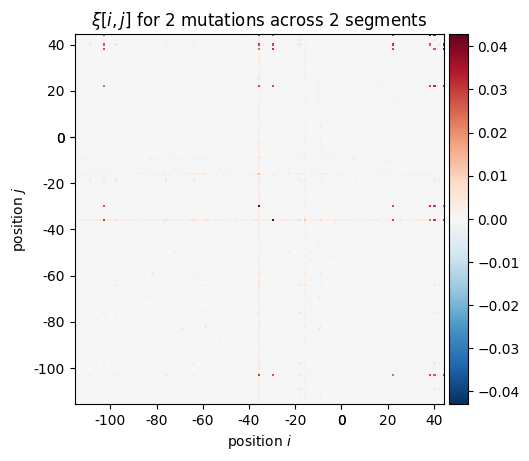

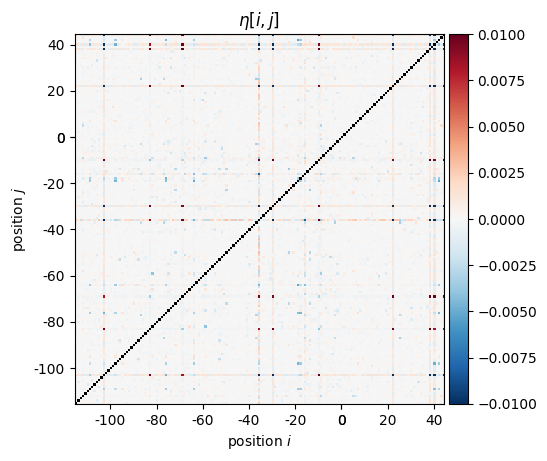

In [41]:
if SEGMENT_SIZE == 2:
    profile_groups = [
        [((0,1),(0,0)),((1,0),(0,0))], # 1 mutation (left)
        [((0,0),(1,0)),((0,0),(0,1))], # 1 mutation (right)
        [((0,1),(0,1)),((1,0),(1,0)),((0,1),(1,0)),((1,0),(0,1))], # 2 mutations
    ]
elif SEGMENT_SIZE == 1:
    profile_groups = [
        [((1,),(0,))], # 1 mutation (left)
        [((0,),(1,))], # 1 mutation (right)
        [((1,),(1,))], # 2 mutations
    ]
else:
    raise RuntimeError(f"Can't handle SEGMENT_SIZE={SEGMENT_SIZE}")

(xi_1mut_left, xi_1mut_right, xi_2mut), _ = compute_expression_shift_by_pairwise_mutation(
    seqs, expression, wt_seq,
    segment_size=SEGMENT_SIZE,
    profile_groups=profile_groups
)

assert np.allclose(xi_1mut_left, xi_1mut_right.T, equal_nan=True)


# All instances with one mutation at each position. 
ax = plot_data_2d(
    xi_2mut,
)
ax.set_title("$\\xi[i,j]$ for 2 mutations across 2 segments")
plt.savefig(f"{OUTDIR}/v2_xi_double.pdf")

# Difference between two-segment mutations and *two* one-segment mutations
eta_v2 = xi_2mut - xi_1mut_right - xi_1mut_left
ax = plot_data_2d(
    eta_v2,
    vmax = 0.01
)
ax.set_title("$\\eta[i,j]$")
plt.savefig(f"{OUTDIR}/v2_eta.pdf")

print("eta is symmetric? ", np.allclose(eta_v2, eta_v2.T, equal_nan=True))

A third version of the computation, where we compute the single-mutation expression shift without any condition on a second segment.
This is computed as $\eta_3 = \xi_{i,j} - \xi_i - \xi_i^T$.
This is equivalent to the computation performed via the function `compute_total_expression_by_pairwise_bp_mutation` defined below.

In [37]:
print("Eta ranges:")
print("eta_v1:", np.nanmin(eta_v1), np.nanmax(eta_v1))
print("eta_v2:", np.nanmin(eta_v2), np.nanmax(eta_v2))
print("eta_v3:", np.nanmin(eta_v3), np.nanmax(eta_v3))

Eta ranges:
eta_v1: -0.041448057 0.0030930638
eta_v2: -0.041444063 0.01326257
eta_v3: -0.003504753 0.039565563
